# Diabetes Risk Prediction
Predicting diabetes likelihood from clinical measurements using a Random Forest
classifier, trained on the Pima Indians Diabetes dataset.

In [16]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies' , 'Glucose' , 'BloodPressure' , 'SkinThickness' , 'Insulin' , 'BMI' , 'DiabituesPedigreeFunction' , 'Age' , 'Outcome']

df = pd.read_csv(url, names=columns)
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabituesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [17]:
df.info() # pulls information from the data set - data types, missing values
df.describe() # mean, min, max for each column
df['Outcome'].value_counts # estimates how balanced the data set is

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Pregnancies                768 non-null    int64  
 1   Glucose                    768 non-null    int64  
 2   BloodPressure              768 non-null    int64  
 3   SkinThickness              768 non-null    int64  
 4   Insulin                    768 non-null    int64  
 5   BMI                        768 non-null    float64
 6   DiabituesPedigreeFunction  768 non-null    float64
 7   Age                        768 non-null    int64  
 8   Outcome                    768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


<bound method IndexOpsMixin.value_counts of 0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64>

## Clean the Data

Several columns (Glucose, BloodPressure, SkinThickness, Insulin, BMI) contain
zero values that aren't biologically possible — these are actually missing
values recorded as 0. I replace them with the median of each column rather
than dropping rows, to preserve as much data as possible.

In [18]:
import numpy as np

cols_with_bad_zeros =  ['Glucose' , 'BloodPressure' , 'SkinThickness' , 'Insulin' ,'BMI']
df[cols_with_bad_zeros] = df[cols_with_bad_zeros].replace(0, np.nan)

df[cols_with_bad_zeros] = df[cols_with_bad_zeros].fillna(df[cols_with_bad_zeros].median())
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabituesPedigreeFunction,0
Age,0
Outcome,0


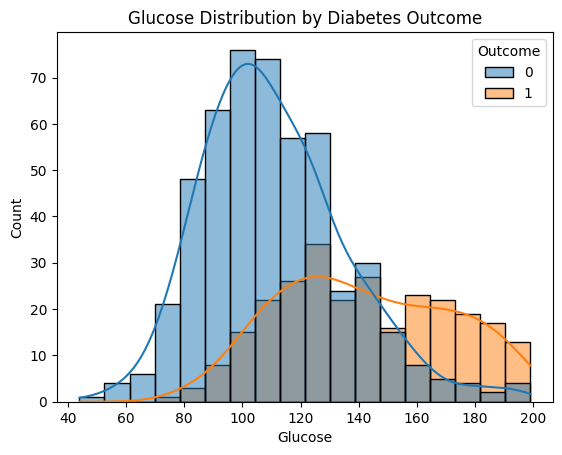

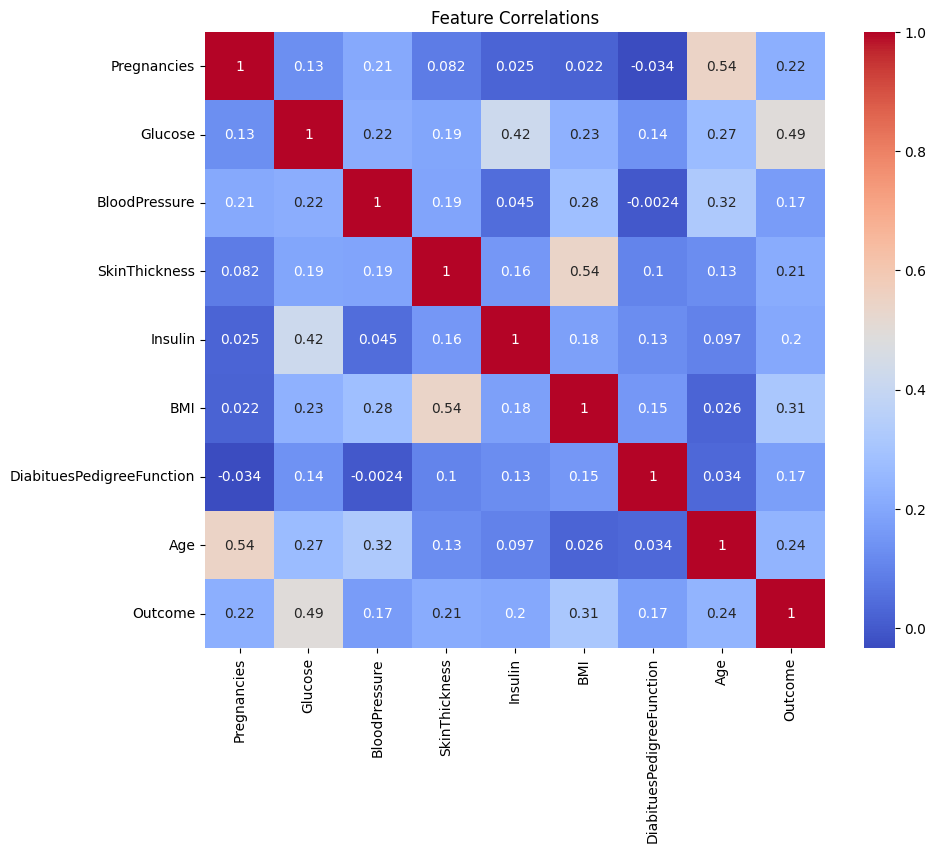

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# distribution of glucose by outcome
sns.histplot(data=df, x='Glucose', hue='Outcome', kde=True)
plt.title('Glucose Distribution by Diabetes Outcome')
plt.show()

# correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlations')
plt.show()

## Train the Model

Splitting the data into training (80%) and test (20%) sets, then training a
Random Forest classifier to predict diabetes outcome from the clinical
features. The test set is held out so the model is evaluated only on data
it hasn't seen.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7467532467532467
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



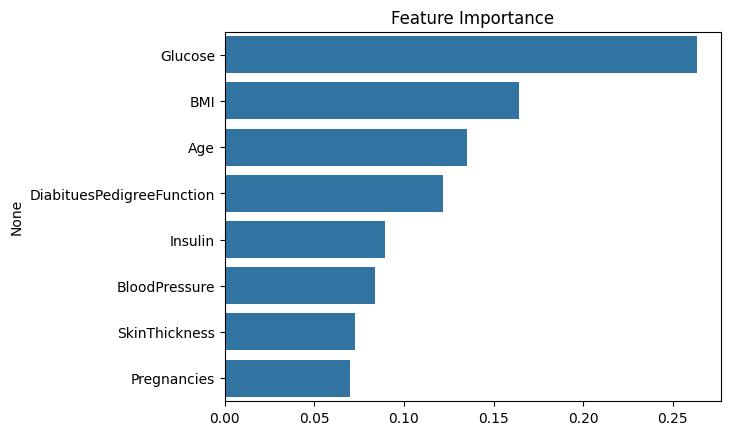

In [21]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=importances.values, y=importances.index)
plt.title('Feature Importance')
plt.show()

In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred))
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

Accuracy: 0.7467532467532467
Glucose                      0.263453
BMI                          0.164118
Age                          0.134927
DiabituesPedigreeFunction    0.121819
Insulin                      0.089248
BloodPressure                0.084062
SkinThickness                0.072432
Pregnancies                  0.069942
dtype: float64


## Summary

This project explored the Pima Indians Diabetes dataset to predict whether a
patient is likely to have diabetes based on clinical measurements including
glucose level, BMI, age, blood pressure, and other health indicators.

After cleaning the data (replacing biologically implausible zero values in
Glucose, BloodPressure, SkinThickness, Insulin, and BMI with median values),
I trained a Random Forest classifier on 80% of the data and evaluated it on
the remaining 20% it had never seen. The model achieved an accuracy of
**74.7%** on the test set.

The most important predictive features were **Glucose** (26.3%),
**BMI** (16.4%), and **Age** (13.5%) — which aligns with established
clinical knowledge, since elevated blood glucose and higher BMI are
well-established risk factors for type 2 diabetes, and diabetes risk is
also known to increase with age.

**Limitations:** This dataset is relatively small (768 patients) and drawn
from a specific population (Pima Indian women), so the model's patterns may
not generalize to other populations. Zero-value imputation using the median
is a simplification — a more rigorous approach might use more advanced
imputation techniques such as KNN imputation or regression-based imputation.